In [29]:
import os
os.environ["PYART_QUIET"] = "True"

import pyart
import cftime
import numpy as np
import ultraplot as pplt
import matplotlib.pyplot as plt
from matplotlib import colors
import opol_processing

In [30]:
# CSU RadarTools HID classification labels and colors
hid_labels = ['Drizzle', 'Rain', 'Ice Crystals', 'Aggregates', 'Wet Snow',
              'Vertical Ice', 'LD Graupel', 'HD Graupel', 'Hail', 'Big Drops']

hid_colors = ['LightBlue', 'MediumBlue', 'DarkOrange', 'LightPink', 'Cyan',
              'DarkGray', 'Lime', 'Yellow', 'Red', 'Fuchsia']

cmap_hid = colors.ListedColormap(hid_colors)
norm_hid = colors.BoundaryNorm(np.arange(0.5, 11.5, 1), cmap_hid.N)

In [31]:
infile = "/home/vlouf/Downloads/9776HUB-PPIVol-20260518-153000.cfradial.nc"
radar = pyart.io.read_cfradial(infile)
gr = pyart.graph.RadarDisplay(radar)
print("\n".join(radar.fields.keys()))

cross_correlation_ratio
temperature
corrected_reflectivity
corrected_differential_phase
corrected_specific_differential_phase
corrected_velocity
attenuation_corrected_reflectivity
corrected_differential_reflectivity
path_integrated_differential_attenuation
radar_echo_classification
radar_estimated_rain_rate
normalized_intercept_parameter
median_volume_diameter
radar_estimated_snow_rate
total_power
reflectivity
differential_reflectivity
velocity
differential_phase
signal_to_noise_ratio
spectrum_width
signal_quality_index


In [32]:
def find_sweep_elevation(radar, target_elevation):
    """
    Find the sweep index that is closest to the target elevation.
    """
    elevations = radar.fixed_angle['data']
    sweep_index = np.argmin(np.abs(elevations - target_elevation))
    return sweep_index

In [33]:
# Gate filtering to exclude invalid data points
gf = pyart.filters.GateFilter(radar)

sw = find_sweep_elevation(radar, 1.2)  # Get the sweep index for 1.2 degrees elevation
angle = radar.fixed_angle['data'][sw]
date = cftime.num2pydate(radar.time['data'][0], radar.time['units'], calendar=radar.time['calendar'])
lat = radar.latitude['data'][0]
lon = radar.longitude['data'][0]

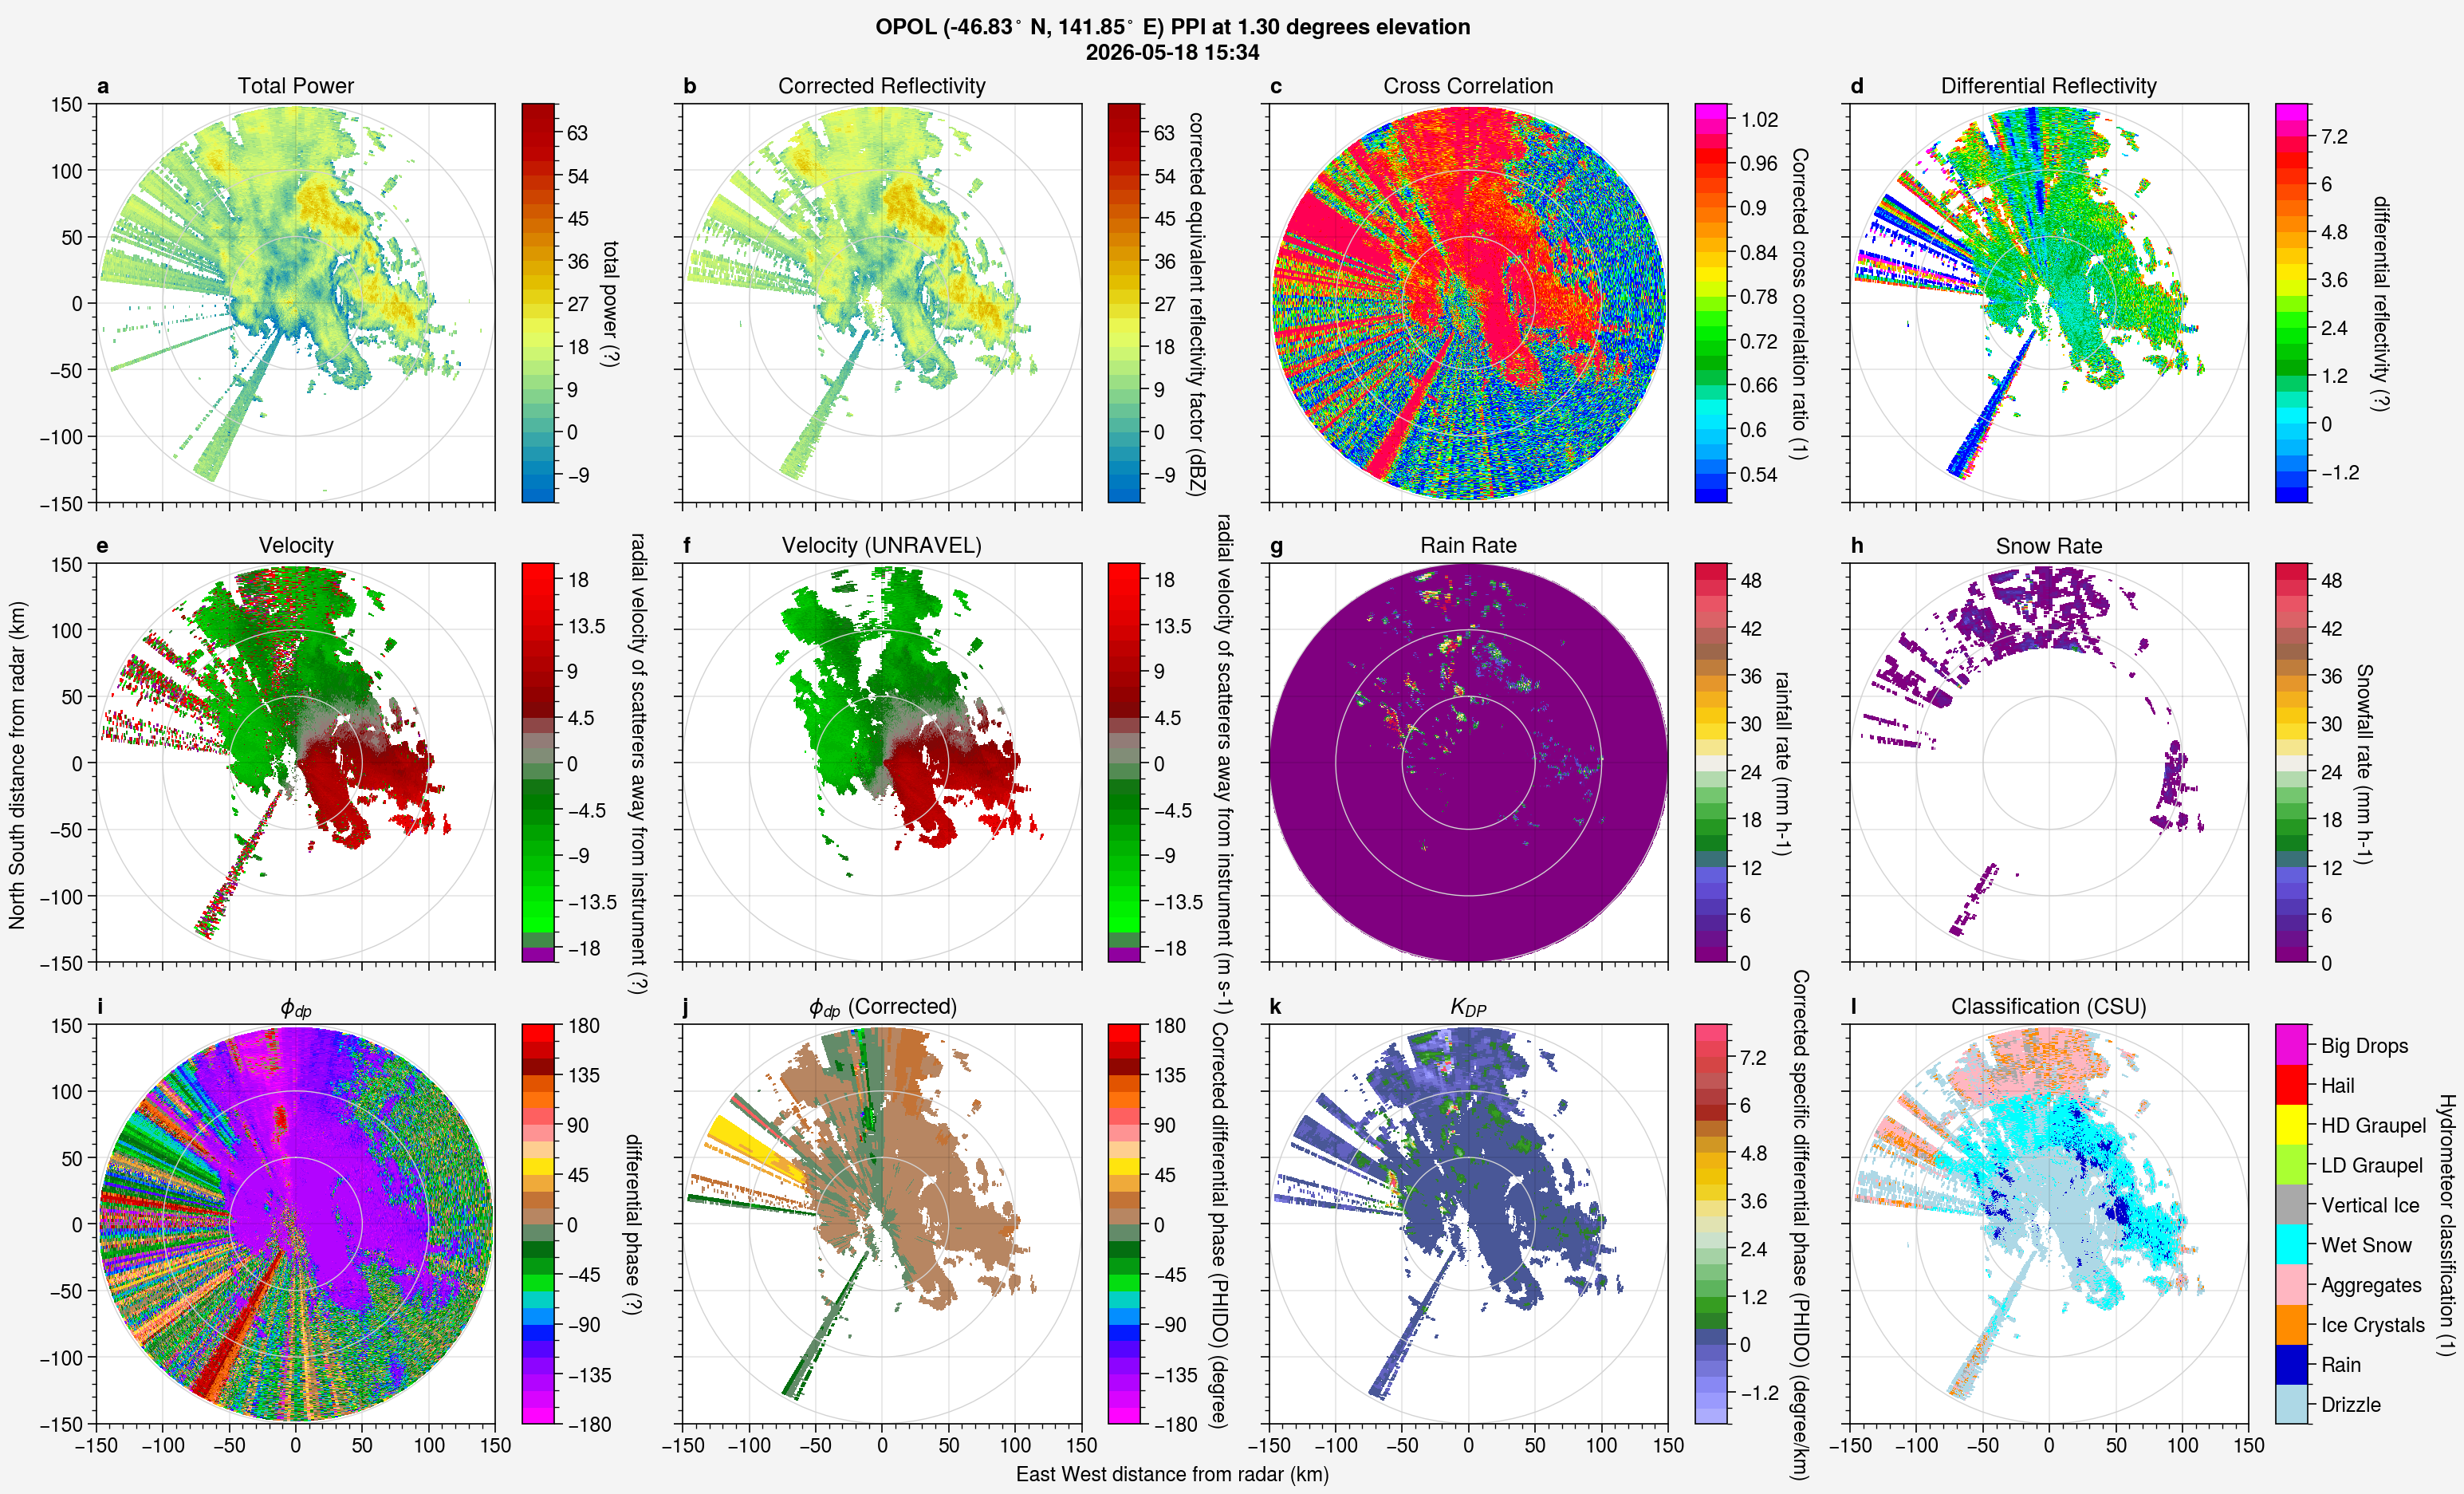

In [34]:
fig = pplt.figure()
axs = fig.subplots(nrows=3, ncols=4)
im = [None] * len(axs)

gr.plot_ppi('total_power', ax=axs[0], title='Total Power', vmin=-15, vmax=70, cmap="HomeyerRainbow", sweep=sw, levels=32)
gr.plot_ppi('corrected_reflectivity', ax=axs[1], title='Corrected Reflectivity', vmin=-15, vmax=70, cmap="HomeyerRainbow", sweep=sw, levels=32)
gr.plot_ppi('cross_correlation_ratio', ax=axs[2], title='Cross Correlation', vmin=0.5, vmax=1.05, cmap="RefDiff", sweep=sw, levels=32)
gr.plot_ppi('differential_reflectivity', ax=axs[3], title='Differential Reflectivity', vmin=-2, vmax=8, cmap="RefDiff", sweep=sw, levels=32, gatefilter=gf)

gr.plot_ppi('velocity', ax=axs[4], title='Velocity', vmin=-20, vmax=20, cmap="NWSVel", sweep=sw, levels=32, gatefilter=gf)
gr.plot_ppi('corrected_velocity', ax=axs[5], title='Velocity (UNRAVEL)', vmin=-20, vmax=20, cmap="NWSVel", sweep=sw, levels=32)
gr.plot_ppi('radar_estimated_rain_rate', ax=axs[6], title='Rain Rate', vmin=0, vmax=50, cmap="RRate11", sweep=sw, levels=32)
gr.plot_ppi('radar_estimated_snow_rate', ax=axs[7], title='Snow Rate', vmin=0, vmax=50, cmap="RRate11", sweep=sw, levels=32)

gr.plot_ppi('differential_phase', ax=axs[8], title=r'$\phi_{dp}$', vmin=-180, vmax=180, cmap="Wild25", sweep=sw, levels=32)
gr.plot_ppi('corrected_differential_phase', ax=axs[9], title=r'$\phi_{dp}$ (Corrected)', vmin=-180, vmax=180, cmap="Wild25", sweep=sw, levels=32)
gr.plot_ppi('corrected_specific_differential_phase', ax=axs[10], title=r'$K_{DP}$', vmin=-2, vmax=8, cmap="Theodore16", sweep=sw, levels=32)
gr.plot_ppi('radar_echo_classification', ax=axs[11], title='Classification (CSU)', cmap=cmap_hid, norm=norm_hid, sweep=sw, ticks=np.arange(1, 11), ticklabs=hid_labels)

for a in axs:
    gr.plot_range_rings([50, 100, 150], ax=a, col='lightgray', ls='-', lw=0.5)

axs.format(abc=True, grid=True, suptitle=f"OPOL ({lat:.2f}$^\\circ$ N, {lon:.2f}$^\\circ$ E) PPI at {angle:.2f} degrees elevation\n{date:%Y-%m-%d %H:%M}", xlim=(-150, 150), ylim=(-150, 150), aspect='equal')
plt.show()